In [ ]:
#!pip install iftg

In [ ]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageOps
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import map_coordinates
import random

FONT_PATH = '/content/5kaSansDesign-Ultra.ttf'

def create_text_image(text='1234', font_size=280, img_size=(800, 400), bg_color='white', text_color='black'):
    img = Image.new('RGB', img_size, color=bg_color)
    draw = ImageDraw.Draw(img)

    font = ImageFont.truetype(FONT_PATH, font_size)
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    x = (img_size[0] - text_width) // 2
    y = (img_size[1] - text_height) // 2

    draw.text((x, y), text, font=font, fill=text_color)
    return img

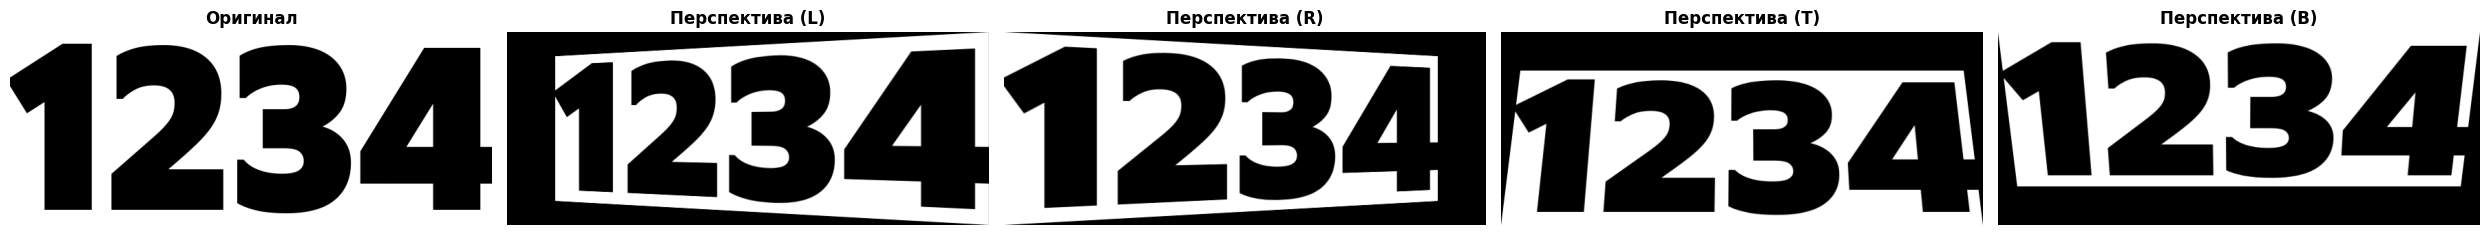

In [ ]:
def perspective_distort(img, strength=0.5, direction='right'):
    """
    Создает эффект перспективы (как фото под углом)
    strength: 0-1, насколько сильный эффект (0.2-0.5 оптимально)
    direction: 'left', 'right', 'top', 'bottom' - какая сторона сужается
    """
    width, height = img.size
    img_array = np.array(img)

    # Определяем точки перспективы
    pts1 = np.float32([[0, 0], [width, 0], [0, height], [width, height]])

    if direction == 'right':
        shrink = int(width * strength)
        pts2 = np.float32([
            [0, 0],
            [width - shrink, shrink // 2],
            [0, height],
            [width - shrink, height - shrink // 2]
        ])
    elif direction == 'left':
        shrink = int(width * strength)
        pts2 = np.float32([
            [shrink, shrink // 2],
            [width, 0],
            [shrink, height - shrink // 2],
            [width, height]
        ])
    elif direction == 'top':
        shrink = int(height * strength)
        pts2 = np.float32([
            [shrink // 2, shrink],
            [width - shrink // 2, shrink],
            [0, height],
            [width, height]
        ])
    else:  # bottom
        shrink = int(height * strength)
        pts2 = np.float32([
            [0, 0],
            [width, 0],
            [shrink // 2, height - shrink],
            [width - shrink // 2, height - shrink]
        ])

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    distorted = cv2.warpPerspective(img_array, matrix, (width, height))
    return Image.fromarray(distorted)

# Создаем исходное изображение с плотной обрезкой (700x280)
IMG_W, IMG_H = 700, 280
original = Image.new('RGB', (IMG_W, IMG_H), color='white')
draw = ImageDraw.Draw(original)
font = ImageFont.truetype(FONT_PATH, 350)
bbox = draw.textbbox((0, 0), '1234', font=font)
t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
draw.text(((IMG_W - t_w)//2 - bbox[0], (IMG_H - t_h)//2 - bbox[1]), '1234', font=font, fill='black')

# Применяем перспективу во всех направлениях
p_right = perspective_distort(original, strength=0.1, direction='right')
p_left = perspective_distort(original, strength=0.1, direction='left')
p_top = perspective_distort(original, strength=0.2, direction='top')
p_bottom = perspective_distort(original, strength=0.2, direction='bottom')

# Визуализация перспективы
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
images = [original, p_left, p_right, p_top, p_bottom]
titles = ['Оригинал', 'Перспектива (L)', 'Перспектива (R)', 'Перспектива (T)', 'Перспектива (B)']
for idx, (img, title) in enumerate(zip(images, titles)):
    axes[idx].imshow(img)
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

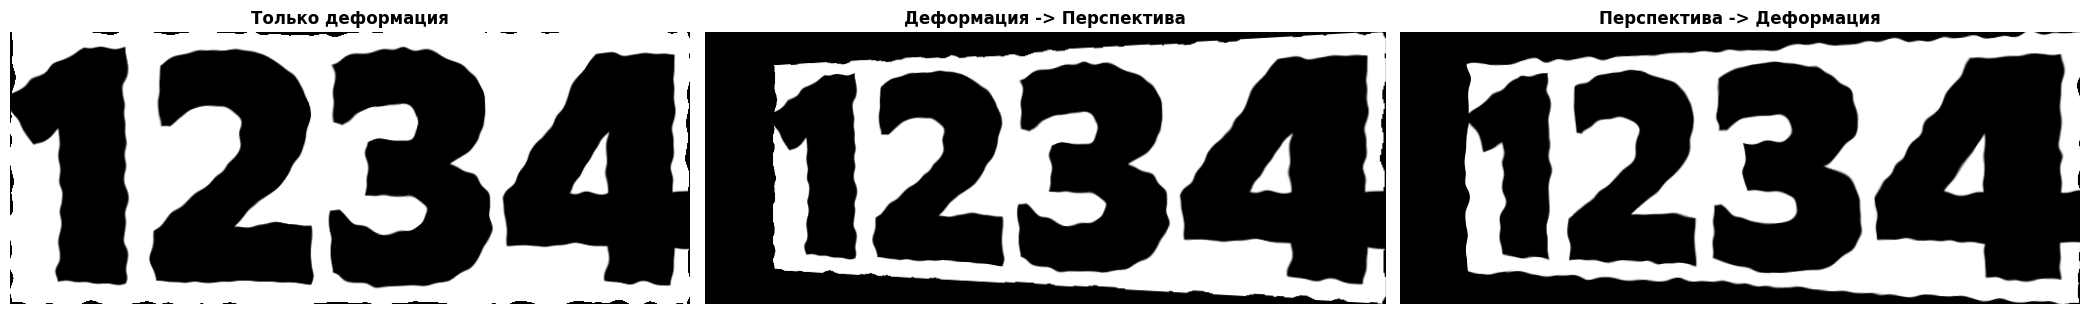

In [ ]:
def elastic_distort(img, alpha=30, sigma=6):
    from scipy.ndimage import map_coordinates
    img_array = np.array(img)
    h, w = img_array.shape[:2]
    c = img_array.shape[2] if len(img_array.shape) == 3 else 1

    dx = np.random.randn(h, w) * alpha
    dy = np.random.randn(h, w) * alpha
    dx = cv2.GaussianBlur(dx, (0, 0), sigma)
    dy = cv2.GaussianBlur(dy, (0, 0), sigma)

    x, y = np.meshgrid(np.arange(w), np.arange(h))
    indices = (y + dy).reshape(-1), (x + dx).reshape(-1)

    if c == 3:
        result = np.zeros_like(img_array)
        for i in range(3):
            result[:,:,i] = map_coordinates(img_array[:,:,i], indices, order=1).reshape(h, w)
    else:
        result = map_coordinates(img_array, indices, order=1).reshape(h, w)

    return Image.fromarray(np.clip(result, 0, 255).astype(np.uint8))

# Подготовка вариантов
# 1. Только эластичность
elastic_only = elastic_distort(original)

# 2. Эластичность -> Перспектива слева
e_then_p = perspective_distort(elastic_only, strength=0.1, direction='left')

# 3. Перспектива слева -> Эластичность
p_then_e = elastic_distort(perspective_distort(original, strength=0.1, direction='left'))

# Визуализация
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
imgs_to_show = [elastic_only, e_then_p, p_then_e]
titls_to_show = ['Только деформация', 'Деформация -> Перспектива', 'Перспектива -> Деформация']

for i, (img, title) in enumerate(zip(imgs_to_show, titls_to_show)):
    ax[i].imshow(img)
    ax[i].set_title(title, fontweight='bold')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

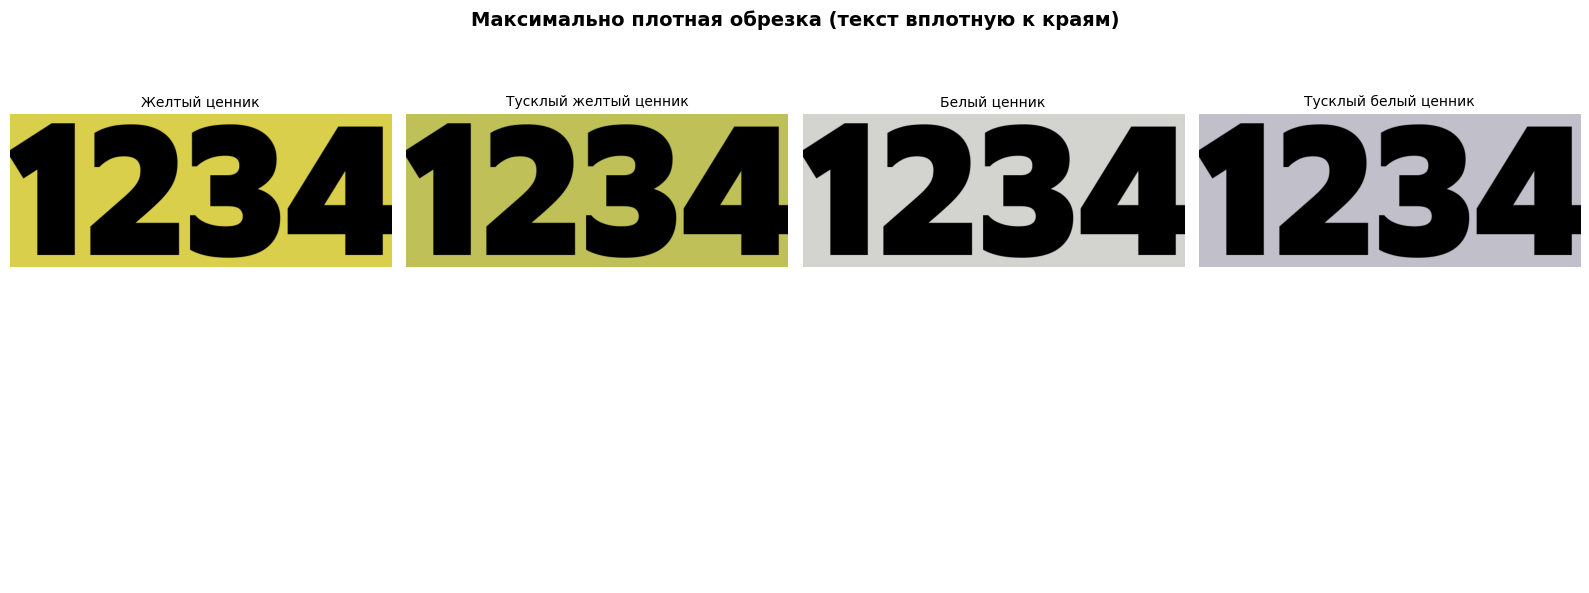

In [ ]:
backgrounds = {
    'Желтый ценник': (217, 207, 75),
    'Тусклый желтый ценник': (191, 192, 88),
    'Белый ценник': (211, 212, 207),
    'Тусклый белый ценник': (193, 191, 202)
}

def create_gradient_bg(size=(800, 400), color1=(220, 220, 220), color2=(180, 180, 180)):
    img = Image.new('RGB', size)
    for y in range(size[1]):
        ratio = y / size[1]
        r = int(color1[0] * (1-ratio) + color2[0] * ratio)
        g = int(color1[1] * (1-ratio) + color2[1] * ratio)
        b = int(color1[2] * (1-ratio) + color2[2] * ratio)
        for x in range(size[0]):
            img.putpixel((x, y), (r, g, b))
    return img

# Новые параметры для плотной обрезки
IMG_W, IMG_H = 700, 280
images_variants = []

for name, color in backgrounds.items():
    if name == 'Тусклый градиент':
        bg = create_gradient_bg(size=(IMG_W, IMG_H))
    else:
        bg = Image.new('RGB', (IMG_W, IMG_H), color=color)

    draw = ImageDraw.Draw(bg)
    # Подбираем размер шрифта так, чтобы он заполнял почти все пространство
    font_size = 350
    font = ImageFont.truetype(FONT_PATH, font_size)

    bbox = draw.textbbox((0, 0), '1234', font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]

    # Вычисляем координаты так, чтобы минимизировать пустые поля
    x = (IMG_W - text_width) // 2 - bbox[0]
    y = (IMG_H - text_height) // 2 - bbox[1]

    draw.text((x, y), '1234', font=font, fill='black')
    images_variants.append((name, bg))

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for idx, (name, img) in enumerate(images_variants):
    axes[idx].imshow(img)
    axes[idx].set_title(name, fontsize=10)
    axes[idx].axis('off')

for idx in range(len(images_variants), 8):
    axes[idx].axis('off')

plt.suptitle('Максимально плотная обрезка (текст вплотную к краям)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

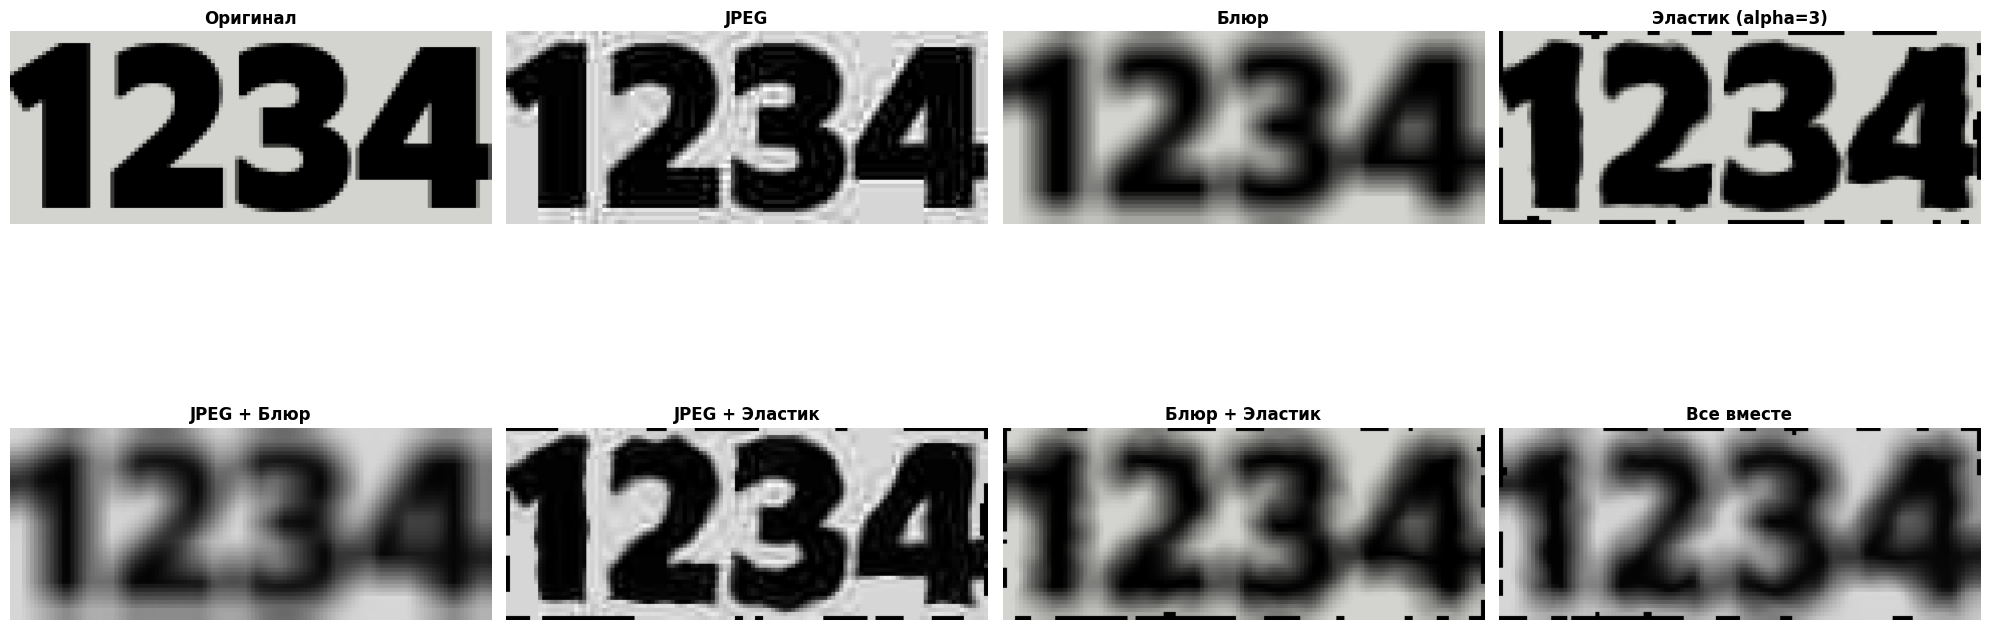

In [ ]:
import albumentations as A
import io
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import map_coordinates

# Базовые настройки
IMG_W, IMG_H = 120, 48
bg_color = (211, 212, 207)
FONT_PATH = '/content/5kaSansDesign-Ultra.ttf'

def get_base_image():
    img = Image.new('RGB', (IMG_W, IMG_H), color=bg_color)
    draw = ImageDraw.Draw(img)
    # Увеличиваем шрифт для плотной обрезки
    font = ImageFont.truetype(FONT_PATH, 60)
    bbox = draw.textbbox((0, 0), '1234', font=font)
    t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    # Смещаем так, чтобы текст заполнял весь холст
    draw.text(((IMG_W - t_w)//2 - bbox[0], (IMG_H - t_h)//2 - bbox[1]), '1234', font=font, fill='black')
    return img

# Функции трансформаций
def apply_blur(img):
    arr = np.array(img)
    # Увеличили лимит блюра для большей интенсивности
    return Image.fromarray(A.Blur(blur_limit=(9, 13), p=1.0)(image=arr)['image'])

def apply_jpeg(img):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=15)
    buf.seek(0)
    return Image.open(buf)

def apply_elastic(img, alpha=3, sigma=2):
    img_array = np.array(img)
    h, w = img_array.shape[:2]
    c = img_array.shape[2] if len(img_array.shape) == 3 else 1

    dx = np.random.randn(h, w) * alpha
    dy = np.random.randn(h, w) * alpha
    dx = cv2.GaussianBlur(dx, (0, 0), sigma)
    dy = cv2.GaussianBlur(dy, (0, 0), sigma)

    x, y = np.meshgrid(np.arange(w), np.arange(h))
    indices = (y + dy).reshape(-1), (x + dx).reshape(-1)

    if c == 3:
        result = np.zeros_like(img_array)
        for i in range(3):
            result[:,:,i] = map_coordinates(img_array[:,:,i], indices, order=1).reshape(h, w)
    else:
        result = map_coordinates(img_array, indices, order=1).reshape(h, w)

    return Image.fromarray(np.clip(result, 0, 255).astype(np.uint8))

base = get_base_image()

# Генерация всех комбинаций
variants = {
    "Оригинал": base,
    "JPEG": apply_jpeg(base),
    "Блюр": apply_blur(base),
    "Эластик (alpha=3)": apply_elastic(base, alpha=3, sigma=2),
    "JPEG + Блюр": apply_blur(apply_jpeg(base)),
    "JPEG + Эластик": apply_elastic(apply_jpeg(base), alpha=3, sigma=2),
    "Блюр + Эластик": apply_elastic(apply_blur(base), alpha=3, sigma=2),
    "Все вместе": apply_elastic(apply_blur(apply_jpeg(base)), alpha=3, sigma=2)
}

# Визуализация
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for idx, (name, img) in enumerate(variants.items()):
    display_img = img.resize((img.width * 8, img.height * 8), Image.NEAREST)
    axes[idx].imshow(display_img)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def add_horizontal_stripe(img, stripe_height_range=(20, 80), stripe_prob=0.7, alpha=0.8):
    """Добавляет случайную горизонтальную белую полосу с высокой непрозрачностью"""
    if random.random() > stripe_prob:
        return img.copy(), "Без полосы"

    img_copy = img.copy().convert('RGBA')
    overlay = Image.new('RGBA', img_copy.size, (255, 255, 255, 0))
    draw = ImageDraw.Draw(overlay)

    w, h = img_copy.size
    stripe_h = random.randint(*stripe_height_range)
    y_start = random.randint(0, max(0, h - stripe_h))
    y_end = y_start + stripe_h

    # Используем высокую непрозрачность (0.7-0.9) для жесткого блика
    hard_alpha = int(255 * random.uniform(0.7, 0.9))
    draw.rectangle([0, y_start, w, y_end], fill=(255, 255, 255, hard_alpha))

    combined = Image.alpha_composite(img_copy, overlay)
    return combined.convert('RGB'), f"Полоса {stripe_h}px, alpha={hard_alpha/255:.2f}"

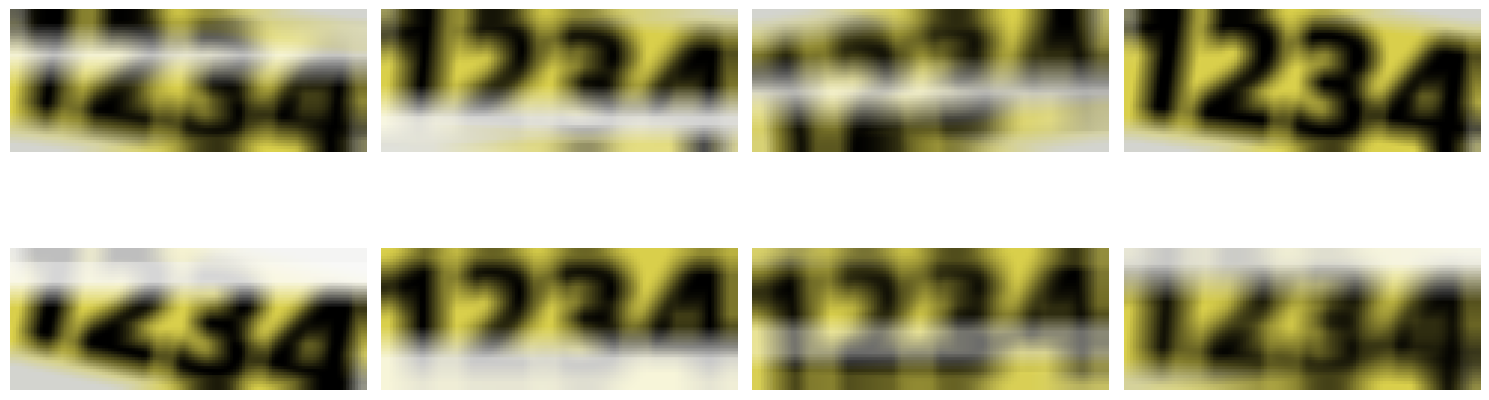

In [ ]:
SMALL_W, SMALL_H = 120, 48


def apply_rotation(img, limit=15):
    """Добавляет случайный поворот в диапазоне +-limit градусов"""
    angle = random.uniform(-limit, limit)
    # Используем expand=True, чтобы не обрезать углы при повороте,
    # но затем возвращаем к исходному размеру или оставляем как есть
    # Для ценников обычно лучше поворачивать с заполнением фона
    return img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=bg_color)

# Пример использования в пайплайне:
def generate_with_rotation(text, bg_color):
    # 1. База
    img = Image.new('RGB', (SMALL_W, SMALL_H), color=bg_color)
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(FONT_PATH, 60)
    bbox = draw.textbbox((0, 0), text, font=font)
    t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((SMALL_W - t_w)//2 - bbox[0], (SMALL_H - t_h)//2 - bbox[1]), text, font=font, fill='black')

    # 2. Поворот +-15 градусов
    img = apply_rotation(img, limit=15)

    # 3. Остальные эффекты
    if random.random() > 0.3:
        img, _ = add_horizontal_stripe(img, stripe_height_range=(5, 15), stripe_prob=1.0, alpha=random.uniform(0.2, 0.5))
    img = apply_blur(img)

    return img

# Визуализация поворотов
rotation_examples = []
for _ in range(8):
    rotation_examples.append(generate_with_rotation('1234', (217, 207, 75)))

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
for idx, img in enumerate(rotation_examples):
    axes[idx].imshow(img.resize((img.width * 4, img.height * 4), Image.NEAREST))
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

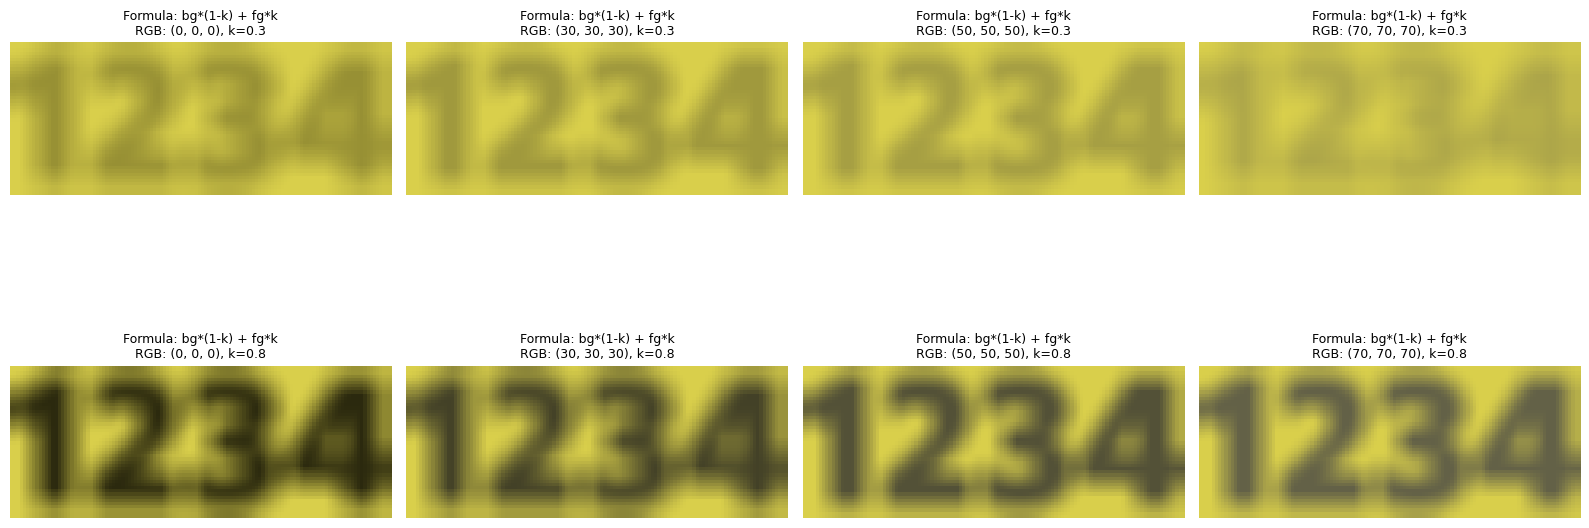

In [ ]:
# Эксперимент с явным Alpha Blending по формуле: bg * (1 - k) + text * k
import numpy as np

black_variants = [
    (0, 0, 0),       # Чистый черный
    (30, 30, 30),    # Глубокий серый
    (50, 50, 50),    # Темно-серый
    (70, 70, 70)     # Осветленный черный
]

alphas = [0.3, 0.8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=100)

for row_idx, alpha_val in enumerate(alphas):
    for col_idx, color_val in enumerate(black_variants):
        # 1. Подготовка массивов (float для точности вычислений)
        bg_color = np.array([217, 207, 75], dtype=np.float32) # Желтый фон
        text_color = np.array(color_val, dtype=np.float32)

        # 2. Создаем маску текста (текст = 1.0, фон = 0.0)
        mask_img = Image.new('L', (SMALL_W, SMALL_H), 0)
        draw = ImageDraw.Draw(mask_img)
        font = ImageFont.truetype(FONT_PATH, 60)
        bbox = draw.textbbox((0, 0), '1234', font=font)
        t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((SMALL_W - t_w)//2 - bbox[0], (SMALL_H - t_h)//2 - bbox[1]), '1234', font=font, fill=255)

        mask = np.array(mask_img).astype(np.float32) / 255.0

        # 3. Применяем формулу: Result = Background * (1 - k*mask) + Text * (k*mask)
        # Здесь k = alpha_val. Маска определяет, где именно находится текст.
        k = alpha_val

        # Создаем пустой холст цвета фона
        out = np.ones((SMALL_H, SMALL_W, 3), dtype=np.float32) * bg_color

        # Смешиваем попиксельно только там, где есть маска текста
        for c in range(3):
            out[:,:,c] = out[:,:,c] * (1 - k * mask) + text_color[c] * (k * mask)

        img = Image.fromarray(out.astype(np.uint8))
        img = apply_blur(img)

        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_title(f'Formula: bg*(1-k) + fg*k\nRGB: {color_val}, k={alpha_val}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def generate_combined_variant(text, bg_color, max_angle=30, fixed_angle=None):
    # 1. Параметры шрифта и цвета
    font_size = 62
    font = ImageFont.truetype(FONT_PATH, font_size)

    # Базовый цвет текста ~40/40/40
    c_offset = random.randint(-15, 15)
    text_rgb = (max(0, 40 + c_offset), max(0, 40 + c_offset), max(0, 40 + c_offset))

    # Альфа-блендинг (k ~ 0.5-0.8) - Сделали чуть выше минимум для мягкости
    k_val = random.uniform(0.5, 0.8)
    alpha = int(255 * k_val)
    text_color = (*text_rgb, alpha)

    dummy_img = Image.new('RGB', (1, 1))
    dummy_draw = ImageDraw.Draw(dummy_img)
    bbox = dummy_draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]

    base_w, base_h = tw + 4, th + 10

    # 2. Создание прозрачного текстового слоя (only text with its alpha)
    txt_layer = Image.new('RGBA', (base_w, base_h), (0, 0, 0, 0))
    draw_txt = ImageDraw.Draw(txt_layer)
    draw_txt.text(((base_w - tw)//2 - bbox[0], (base_h - th)//2 - bbox[1]), text, font=font, fill=text_color)

    # 3. Создание фонового изображения, наложение полосы, затем наложение текстового слоя
    # Создаем фоновое изображение в режиме RGB (для add_horizontal_stripe)
    bg_img_for_composition = Image.new('RGB', (base_w, base_h), color=bg_color)

    # Накладываем горизонтальную полосу на фоновое изображение ДО поворота
    if random.random() > 0.3:
        bg_img_for_composition, _ = add_horizontal_stripe(bg_img_for_composition, stripe_height_range=(5, 12), stripe_prob=1.0, alpha=random.uniform(0.1, 0.25))

    # Преобразуем фон с полосой в RGBA для корректного наложения текстового слоя
    bg_img_for_composition_rgba = bg_img_for_composition.convert('RGBA')

    # Накладываем текстовый слой (txt_layer) на фоновое изображение с полосой
    # Текст уже правильно расположен в txt_layer (base_w, base_h)
    img_with_text_and_stripe = Image.alpha_composite(bg_img_for_composition_rgba, txt_layer)

    # 4. Поворот объединенного изображения (фон + текст + полоса)
    angle = fixed_angle if fixed_angle is not None else random.uniform(-max_angle, max_angle)
    # При расширении области во время поворота, заполняем ее исходным цветом фона (полностью непрозрачным)
    rotated_combined_img = img_with_text_and_stripe.rotate(angle, resample=Image.BICUBIC, expand=True, fillcolor=(*bg_color, 255))

    # Результат `rotated_combined_img` - это RGBA изображение, преобразуем его в RGB для остальной части пайплайна
    img = rotated_combined_img.convert('RGB')

    # 5. Блюр
    img = apply_blur(img)

    # 6. Перспектива (p=0.5)
    if random.random() < 0.5:
        direction = random.choice(['left', 'right', 'top', 'bottom'])
        def perspective_distort_with_bg(img, strength, direction, bg_color):
            arr = np.array(img)
            h, w = arr.shape[:2]
            pts1 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])
            shrink = int((w if direction in ['left', 'right'] else h) * strength)
            if direction == 'right':
                pts2 = np.float32([[0, 0], [w - shrink, shrink // 2], [0, h], [w - shrink, h - shrink // 2]])
            elif direction == 'left':
                pts2 = np.float32([[shrink, shrink // 2], [w, 0], [shrink, h - shrink // 2], [w, h]])
            elif direction == 'top':
                pts2 = np.float32([[shrink // 2, shrink], [w - shrink // 2, shrink], [0, h], [w, h]])
            else:
                pts2 = np.float32([[0, 0], [w, 0], [shrink // 2, h - shrink], [w - shrink // 2, h - shrink]])
            matrix = cv2.getPerspectiveTransform(pts1, pts2)
            return Image.fromarray(cv2.warpPerspective(arr, matrix, (w, h), borderValue=bg_color))
        img = perspective_distort_with_bg(img, strength=random.uniform(0.05, 0.08), direction=direction, bg_color=tuple(int(c) for c in bg_color))

    # 7. Виньетка/Освещение  - Уменьшили силу strength для мягкости
    if random.random() < 0.3:
        img = apply_vignette(img, strength=random.uniform(0.3, 0.75), radius=random.uniform(1.0, 1.4))

    return img

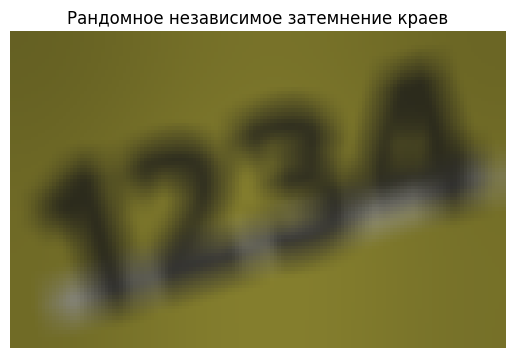

In [ ]:
def apply_vignette(img, strength=0.8, radius=0.75):
    """Добавляет эффект независимого и рандомного затемнения краев"""
    width, height = img.size

    # Создаем базовую сетку
    X, Y = np.meshgrid(np.linspace(-1, 1, width), np.linspace(-1, 1, height))

    # Добавляем рандомное смещение центра и легкое искажение осей для каждого края
    center_x = random.uniform(-0.2, 0.2)
    center_y = random.uniform(-0.2, 0.2)
    scale_x = random.uniform(0.8, 1.2)
    scale_y = random.uniform(0.8, 1.2)

    # Вычисляем дистанцию с учетом случайных деформаций
    dist = np.sqrt(((X - center_x) * scale_x)**2 + ((Y - center_y) * scale_y)**2)

    # Создаем маску с рандомными параметрами плавности
    mask = np.clip((1 - dist / radius) * strength + (1 - strength), 0, 1)

    # Добавляем шум в маску для имитации неравномерности
    noise = np.random.normal(0, 0.02, (height, width))
    mask = np.clip(mask + noise, 0, 1)

    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=width/4)

    # Применяем маску
    img_array = np.array(img).astype(np.float32)
    for i in range(3):
        img_array[:, :, i] *= mask

    return Image.fromarray(np.uint8(np.clip(img_array, 0, 255)))

# Обновляем основной пайплайн
def generate_combined_v3(text, bg_color):
    img = generate_combined_variant(text, bg_color)
    # Параметры теперь создают более хаотичное затемнение
    img = apply_vignette(img, strength=random.uniform(0.4, 0.7), radius=random.uniform(0.9, 1.3))
    return img

# Визуализация примера с независимым затемнением
test_img = generate_combined_v3('1234', backgrounds['Желтый ценник'])
plt.imshow(test_img)
plt.title('Рандомное независимое затемнение краев')
plt.axis('off')
plt.show()

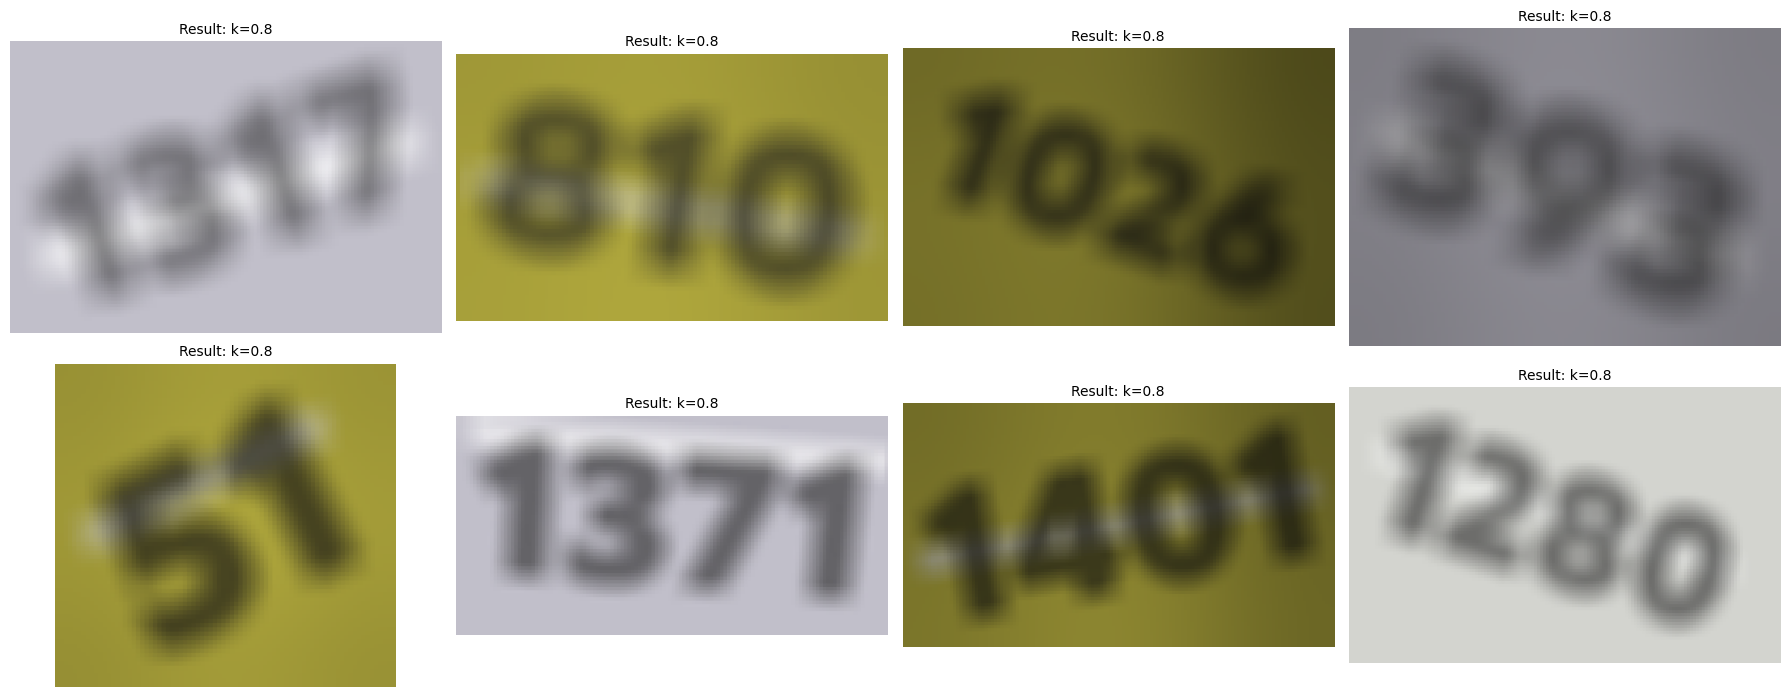

In [ ]:
# Проверка обновленной функции с k=0.8 и рандомным цветом текста
all_bg_colors = list(backgrounds.values())
preview_imgs = []

for _ in range(8):
    color = random.choice(all_bg_colors)
    txt = str(random.randint(10, 1500))
    preview_imgs.append(generate_combined_variant(txt, color))

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for idx, img in enumerate(preview_imgs):
    # Увеличиваем для наглядности
    display_img = img.resize((img.width * 3, img.height * 3), Image.NEAREST)
    axes[idx].imshow(display_img)
    axes[idx].set_title(f"Result: k=0.8", fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

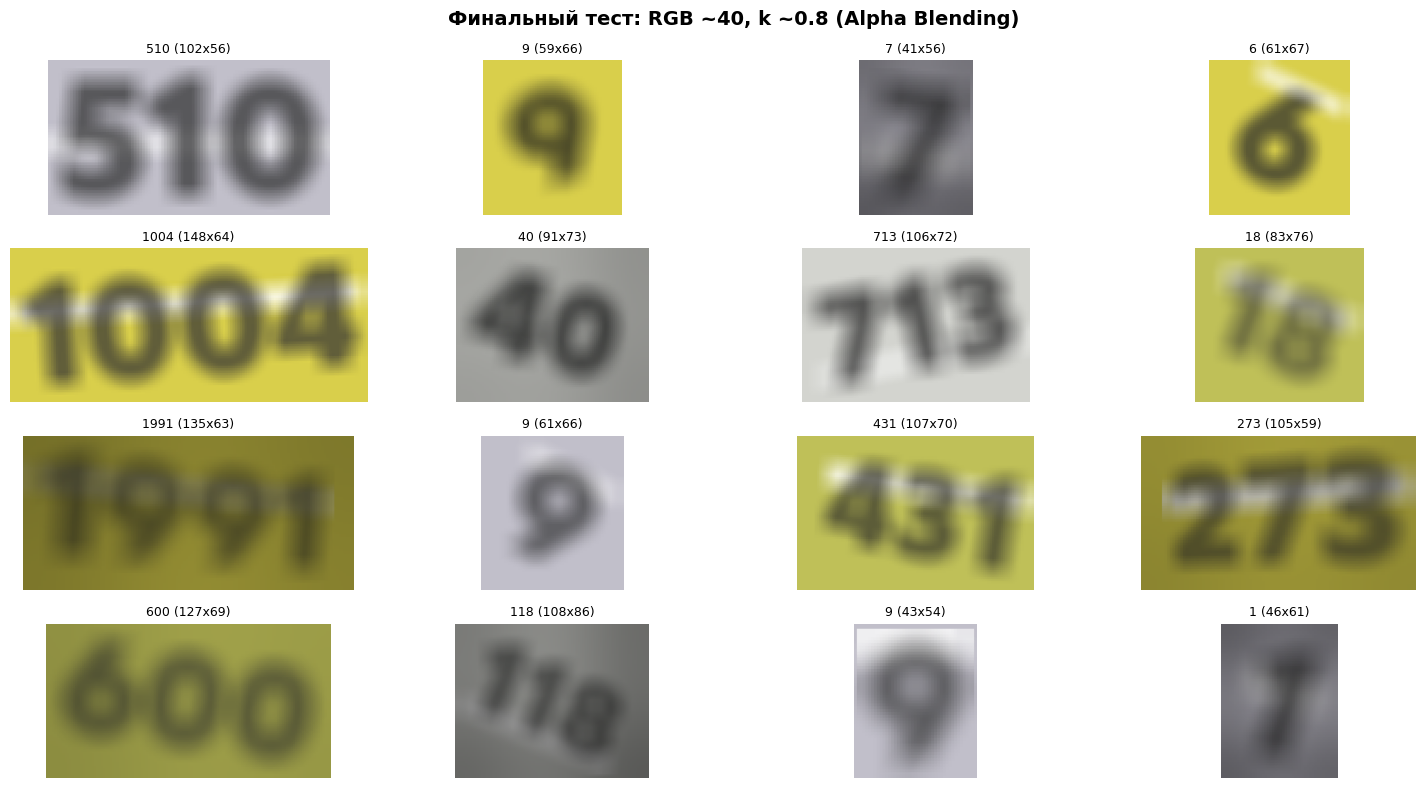

In [ ]:
# Визуализация с обновленным методом (Alpha Blending + Темно-серый текст 40/40/40 + Рандом k)
all_bg_colors = list(backgrounds.values())
combined_images_v2 = []
labels_v2 = []

for i in range(16):
    color = random.choice(all_bg_colors)
    txt = str(random.choice([random.randint(1, 9), random.randint(10, 99), random.randint(100, 999), random.randint(1000, 1999)]))
    combined_images_v2.append(generate_combined_variant(txt, color))
    labels_v2.append(txt)

fig, axes = plt.subplots(4, 4, figsize=(15, 8))
axes = axes.flatten()
for idx, img in enumerate(combined_images_v2):
    display_img = img.resize((img.width * 4, img.height * 4), Image.NEAREST)
    axes[idx].imshow(display_img)
    axes[idx].set_title(f"{labels_v2[idx]} ({img.width}x{img.height})", fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Финальный тест: RGB ~40, k ~0.8 (Alpha Blending)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def plot_compare(real_img_path, num):
  # Путь к реальному изображению
  real_img = Image.open(real_img_path)

  # Генерируем синтетическую картинку (уже с альфа-блендингом внутри)
  bg_yellow = backgrounds['Желтый ценник']
  synthetic_img = generate_combined_variant(f'{num}', bg_yellow)

  # Ресайзим с сохранением прозрачности (если есть)
  synthetic_img_resized = synthetic_img.resize(real_img.size, Image.LANCZOS)

  # Используем DPI для отображения 1:1
  dpi = 100
  total_width = real_img.width + synthetic_img_resized.width + 10
  max_height = real_img.height

  fig, axes = plt.subplots(1, 2, figsize=(total_width/dpi, max_height/dpi), dpi=dpi)

  axes[0].imshow(real_img)
  axes[0].axis('off')

  axes[1].imshow(synthetic_img_resized)
  axes[1].axis('off')

  plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.1)
  plt.show()

In [ ]:
# # Путь к реальному изображению
# real_img_path = '/content/0_10-B4-1D-C8-01-2C_23_2025-11-18-11-06-35.jpg'
# num = 669

# plot_compare(real_img_path, num)

In [ ]:
# # Путь к реальному изображению
# real_img_path = '/content/0_10-B4-1D-C8-06-30_25_2025-11-13-11-01-43.jpg'
# num = 584

# plot_compare(real_img_path, num)

In [ ]:
# real_img_path = '/content/0_10-B4-1D-E0-1D-48_63_2025-11-13-11-06-09.jpg'
# num = 459

# plot_compare(real_img_path, num)

In [ ]:
import os
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def generate_cropped_icon_variant(text, bg_color, icon_path=None, rotation_angle=0):
    font_size = 62
    font = ImageFont.truetype(FONT_PATH, font_size)
    text_color = (40, 40, 40)

    dummy_img = Image.new('RGB', (1, 1))
    dummy_draw = ImageDraw.Draw(dummy_img)
    bbox = dummy_draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]

    icon = None
    icon_w, icon_h = 0, 0
    if icon_path and os.path.exists(icon_path):
        icon = Image.open(icon_path).convert('RGBA')
        aspect = icon.width / icon.height
        icon_h = int(th * 2.0)
        icon_w = int(icon_h * aspect)
        icon = icon.resize((icon_w, icon_h), Image.LANCZOS)

    temp_w, temp_h = tw + icon_w + 300, th + icon_w + 300
    bg_layer = Image.new('RGBA', (temp_w, temp_h), color=(*bg_color, 255))
    ctx, cty = temp_w // 2, temp_h // 2

    if random.random() < 0.8:
        stripe_h = random.randint(10, 20)
        overlay = Image.new('RGBA', bg_layer.size, (0, 0, 0, 0))
        d_stripe = ImageDraw.Draw(overlay)
        s_y = random.randint(cty - 25, cty + 25)
        s_alpha = random.randint(40, 80)
        d_stripe.rectangle([0, s_y, temp_w, s_y + stripe_h], fill=(255, 255, 255, s_alpha))
        bg_layer = Image.alpha_composite(bg_layer, overlay)

    # Настройки отступов
    padding_x = 10
    normal_icon_w = int(th * 0.9 * (icon.width/icon.height)) if icon else 0
    spacing = 14 if icon else 0
    content_width = tw + normal_icon_w + spacing + padding_x
    content_start_x = ctx - content_width // 2
    current_x = content_start_x + padding_x // 2

    if icon:
        icon_x = int(current_x - (icon_w // 2))
        # Смещаем иконку чуть ниже: было -25, стало -20
        icon_y = int(cty - icon_h // 2 - 20)
        bg_layer.paste(icon, (icon_x, icon_y), icon)
        current_x += normal_icon_w + spacing

    draw = ImageDraw.Draw(bg_layer)
    text_y = cty - th // 2 - bbox[1]
    draw.text((current_x - bbox[0], text_y), text, font=font, fill=text_color)

    rotated = bg_layer.rotate(rotation_angle, resample=Image.BICUBIC, expand=False, fillcolor=(*bg_color, 255))

    # Ультра-плотная обрезка по высоте
    angle_rad = abs(np.radians(rotation_angle))
    height_padding = max(0, int(content_width * np.sin(angle_rad)) - 4)

    final_w = content_width
    final_h = th + height_padding

    left = content_start_x
    top = cty - final_h // 2
    right = content_start_x + final_w
    bottom = cty + final_h // 2

    return rotated.crop((left, top, right, bottom)).convert('RGB')

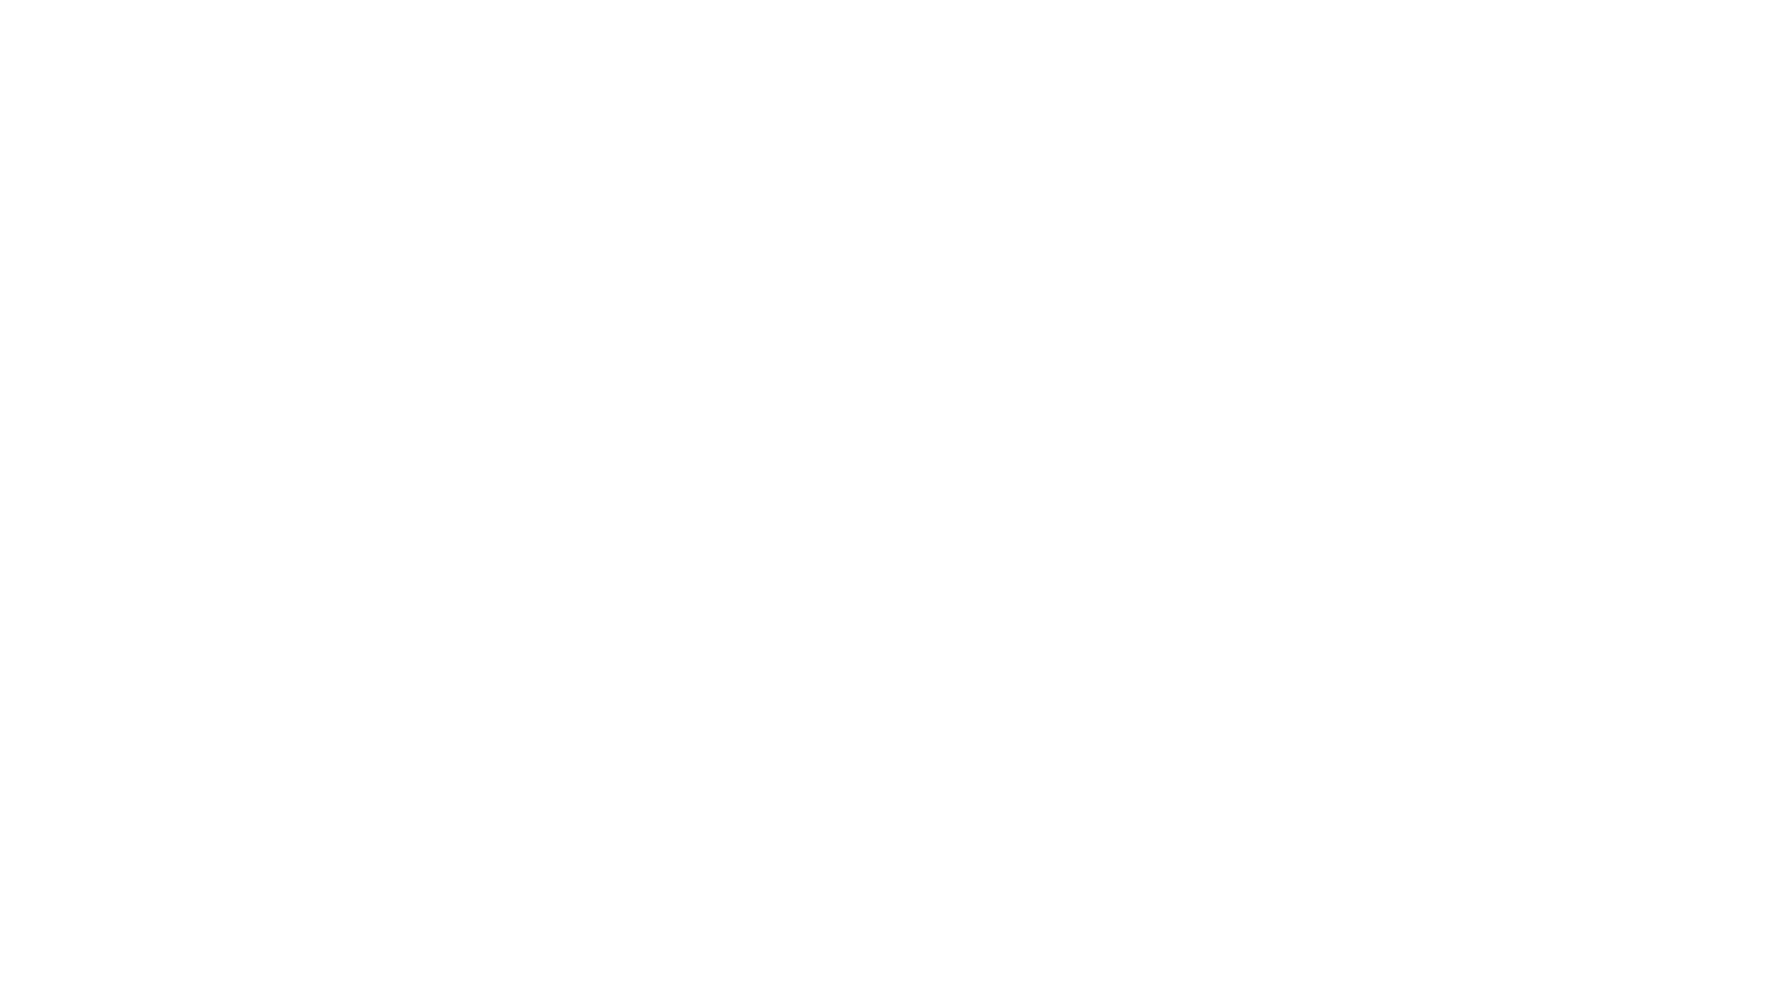

In [ ]:
# Тест с углами
icon_names = ["1", "2", "3", "4"]
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i in range(8):
    name = icon_names[i % 4]
    icon_path = f'/content/{name}.png'
    angle = 20 / 3 * (i - 4) # Увеличим диапазон углов для теста
    if os.path.exists(icon_path):
        color = random.choice(all_bg_colors)
        img = generate_cropped_icon_variant("8999", color, icon_path=icon_path, rotation_angle=angle)
        axes[i].imshow(img)
        axes[i].set_title(f"Угол: {angle:.1f}°\nРазмер: {img.size}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def perspective_distort_clean(img, bg_color, strength=0.15, direction='right'):
    """
    Применяет перспективу и обрезает пустые края,
    используя правильный цвет фона для заполнения.
    """
    arr = np.array(img)
    h, w = arr.shape[:2]
    pts1 = np.float32([[0, 0], [w, 0], [0, h], [w, h]])

    shrink_w = int(w * strength)
    shrink_h = int(h * strength)

    if direction == 'right':
        pts2 = np.float32([[0, 0], [w - shrink_w, shrink_h // 2], [0, h], [w - shrink_w, h - shrink_h // 2]])
        crop_box = (0, 0, w - shrink_w, h)
    elif direction == 'left':
        pts2 = np.float32([[shrink_w, shrink_h // 2], [w, 0], [shrink_w, h - shrink_h // 2], [w, h]])
        crop_box = (shrink_w, 0, w, h)
    elif direction == 'top':
        pts2 = np.float32([[shrink_w // 2, shrink_h], [w - shrink_w // 2, shrink_h], [0, h], [w, h]])
        crop_box = (0, shrink_h, w, h)
    else: # bottom
        pts2 = np.float32([[0, 0], [w, 0], [shrink_w // 2, h - shrink_h], [w - shrink_w // 2, h - shrink_h]])
        crop_box = (0, 0, w, h - shrink_h)

    matrix = cv2.getPerspectiveTransform(pts1, pts2)
    # ВАЖНО: Принудительно используем bg_color для заполнения пустот
    distorted = cv2.warpPerspective(arr, matrix, (w, h), borderValue=bg_color)

    result = Image.fromarray(distorted).crop(crop_box)
    return result

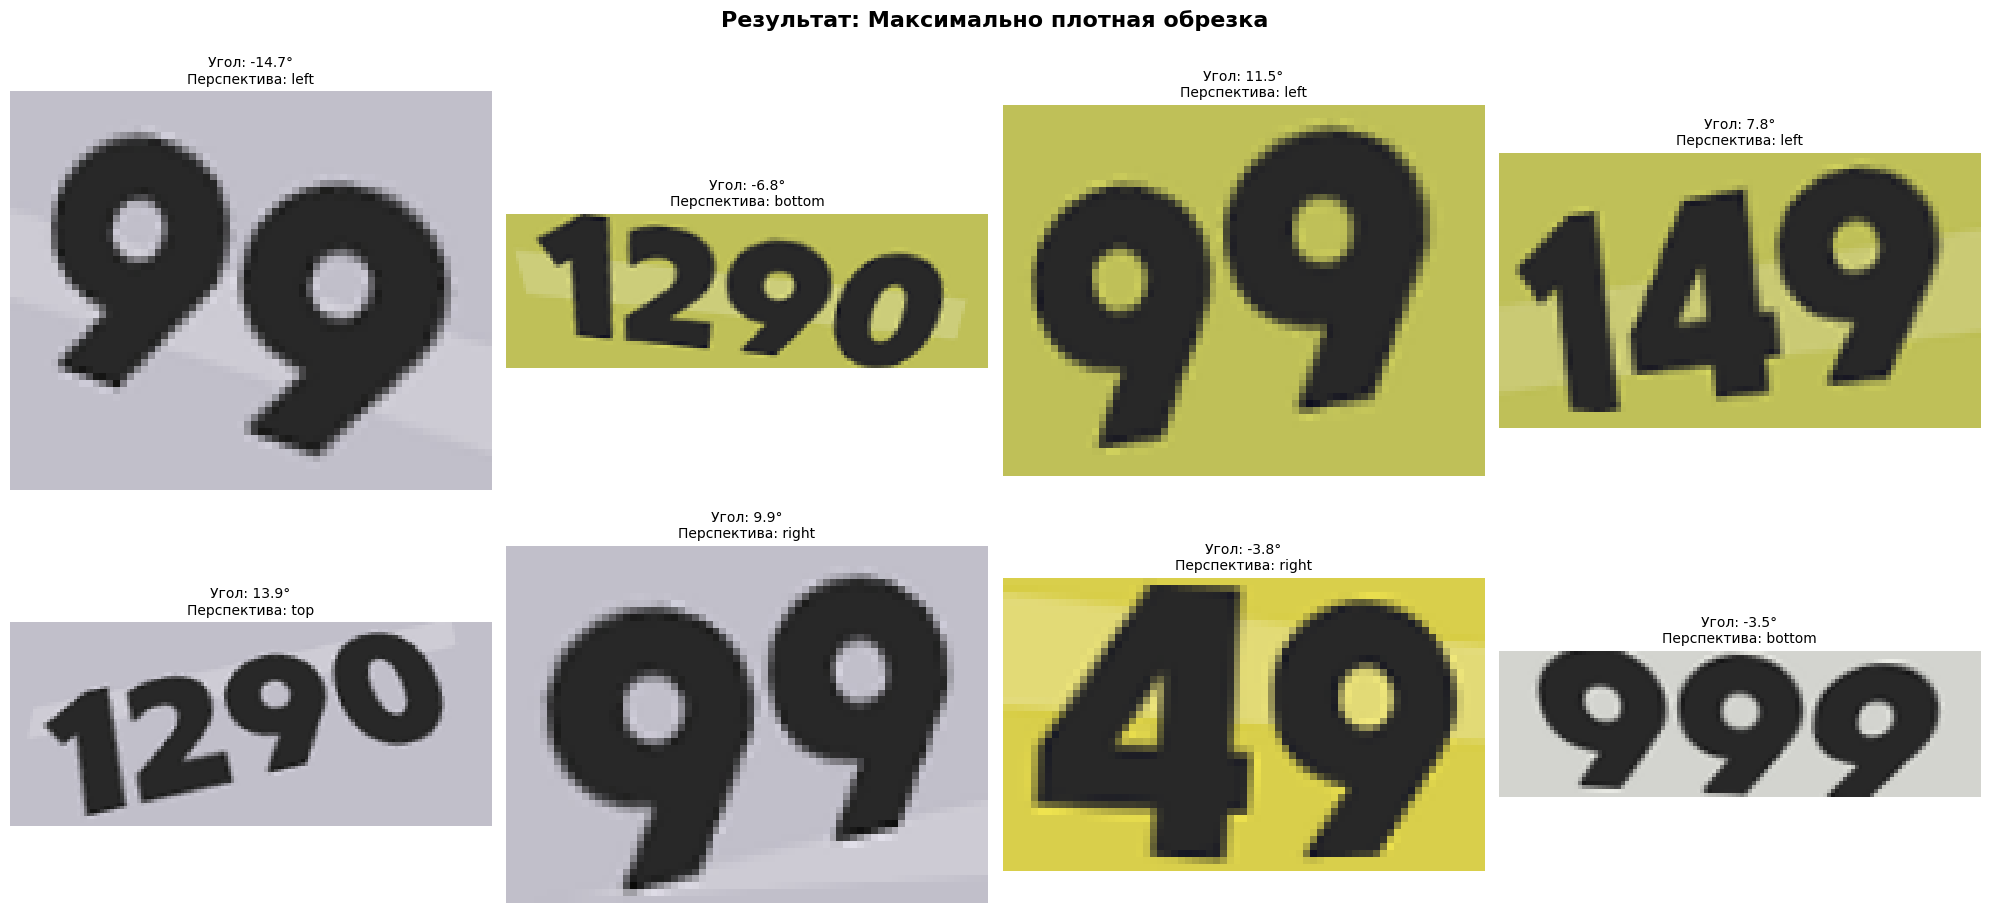

In [ ]:
import random
import matplotlib.pyplot as plt

# Повторный запуск теста с обновленной плотной обрезкой
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

all_bg_colors = list(backgrounds.values())

for i in range(8):
    bg_color = random.choice(all_bg_colors)
    icon_path = f'/content/{random.choice([1, 2, 3, 4])}.png'
    angle = random.uniform(-15, 15)
    direction = random.choice(['left', 'right', 'top', 'bottom'])
    price = str(random.choice([49, 99, 149, 999, 1290]))

    # Генерируем базу с обновленной функцией
    base = generate_cropped_icon_variant(price, bg_color, icon_path=icon_path, rotation_angle=angle)

    # Применяем перспективу
    final_img = perspective_distort_clean(base, bg_color, strength=0.18, direction=direction)

    axes[i].imshow(final_img)
    axes[i].set_title(f"Угол: {angle:.1f}°\nПерспектива: {direction}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Результат: Максимально плотная обрезка", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def generate_combined_variant_with_icons(text, bg_color, icon_path=None, max_angle=30, fixed_angle=None, force_hard_stripe=False):
    # 1. Параметры шрифта и цвета
    font_size = 62
    font = ImageFont.truetype(FONT_PATH, font_size)

    c_offset = random.randint(-15, 15)
    fg_rgb = (max(0, 40 + c_offset), max(0, 40 + c_offset), max(0, 40 + c_offset))

    k_val = random.uniform(0.3, 0.8)

    dummy_img = Image.new('RGB', (1, 1))
    dummy_draw = ImageDraw.Draw(dummy_img)
    bbox = dummy_draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]

    icon_mask = None
    icon_w, icon_h = 0, 0
    if icon_path and os.path.exists(icon_path):
        raw_icon = Image.open(icon_path).convert('RGBA')
        aspect = raw_icon.width / raw_icon.height
        icon_h = int(th * 2.0)
        icon_w = int(icon_h * aspect)
        icon_mask = raw_icon.resize((icon_w, icon_h), Image.LANCZOS).getchannel('A')

    padding_x = 10
    normal_icon_w = int(th * 0.9 * (icon_w/icon_h)) if icon_mask else 0
    spacing = 14 if icon_mask else 0
    content_width = tw + normal_icon_w + spacing + padding_x

    base_w, base_h = content_width + 100, th + 100
    ctx, cty = base_w // 2, base_h // 2

    # 2. Создаем общую маску для текста и иконки
    full_mask = Image.new('L', (base_w, base_h), 0)
    draw_mask = ImageDraw.Draw(full_mask)

    content_start_x = ctx - content_width // 2
    current_x = content_start_x + padding_x // 2

    if icon_mask:
        icon_x = int(current_x - (icon_w // 2))
        icon_y = int(cty - icon_h // 2 - 20)
        full_mask.paste(icon_mask, (icon_x, icon_y))
        current_x += normal_icon_w + spacing

    text_y = cty - th // 2 - bbox[1]
    draw_mask.text((current_x - bbox[0], text_y), text, font=font, fill=255)

    # 3. Применяем формулу блендинга
    bg_arr = np.full((base_h, base_w, 3), bg_color, dtype=np.float32)
    fg_arr = np.full((base_h, base_w, 3), fg_rgb, dtype=np.float32)
    mask_arr = np.array(full_mask).astype(np.float32) / 255.0

    mask_3d = mask_arr[:, :, np.newaxis] * k_val
    out_arr = bg_arr * (1 - mask_3d) + fg_arr * mask_3d

    combined_img = Image.fromarray(out_arr.astype(np.uint8))

    # 4. Полоса (до поворота, чтобы она наклонялась вместе с контентом)
    if force_hard_stripe:
        # Принудительная яркая полоса
        combined_img, _ = add_horizontal_stripe(combined_img, stripe_height_range=(8, 15), stripe_prob=1.0, alpha=random.uniform(0.7, 0.9))
    elif random.random() > 0.3:
        # Обычная слабая полоса
        combined_img, _ = add_horizontal_stripe(combined_img, stripe_height_range=(5, 12), stripe_prob=1.0, alpha=random.uniform(0.1, 0.25))

    # 5. Поворот и плотная обрезка
    angle = fixed_angle if fixed_angle is not None else random.uniform(-max_angle, max_angle)
    rotated = combined_img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=bg_color)

    angle_rad = abs(np.radians(angle))
    height_padding = max(0, int(content_width * np.sin(angle_rad)) - 4)

    left, top = content_start_x, cty - (th + height_padding) // 2
    right, bottom = content_start_x + content_width, cty + (th + height_padding) // 2
    img = rotated.crop((left, top, right, bottom))

    # 6. Пост-обработка
    img = apply_blur(img)
    if random.random() < 0.5:
        direction = random.choice(['left', 'right', 'top', 'bottom'])
        img = perspective_distort_clean(img, bg_color, strength=random.uniform(0.08, 0.2), direction=direction)
    if random.random() < 0.3:
        img = apply_vignette(img, strength=random.uniform(0.3, 0.6), radius=random.uniform(1.0, 1.4))

    return img

In [ ]:
def apply_shakal_effects(img, shakal_factor=0.2, noise_intensity=35):
    """
    Экстремальное ухудшение качества:
    1. Жесткая пикселизация (сильный downscale)
    2. Высокий уровень шума
    """
    w, h = img.size
    # Делаем factor меньше для более крупных пикселей
    small_w = max(1, int(w * shakal_factor))
    small_h = max(1, int(h * shakal_factor))

    shakal_img = img.resize((small_w, small_h), Image.NEAREST)
    shakal_img = shakal_img.resize((w, h), Image.NEAREST)

    arr = np.array(shakal_img).astype(np.int32)
    # Увеличиваем диапазон шума
    noise = np.random.randint(-noise_intensity, noise_intensity, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(arr)

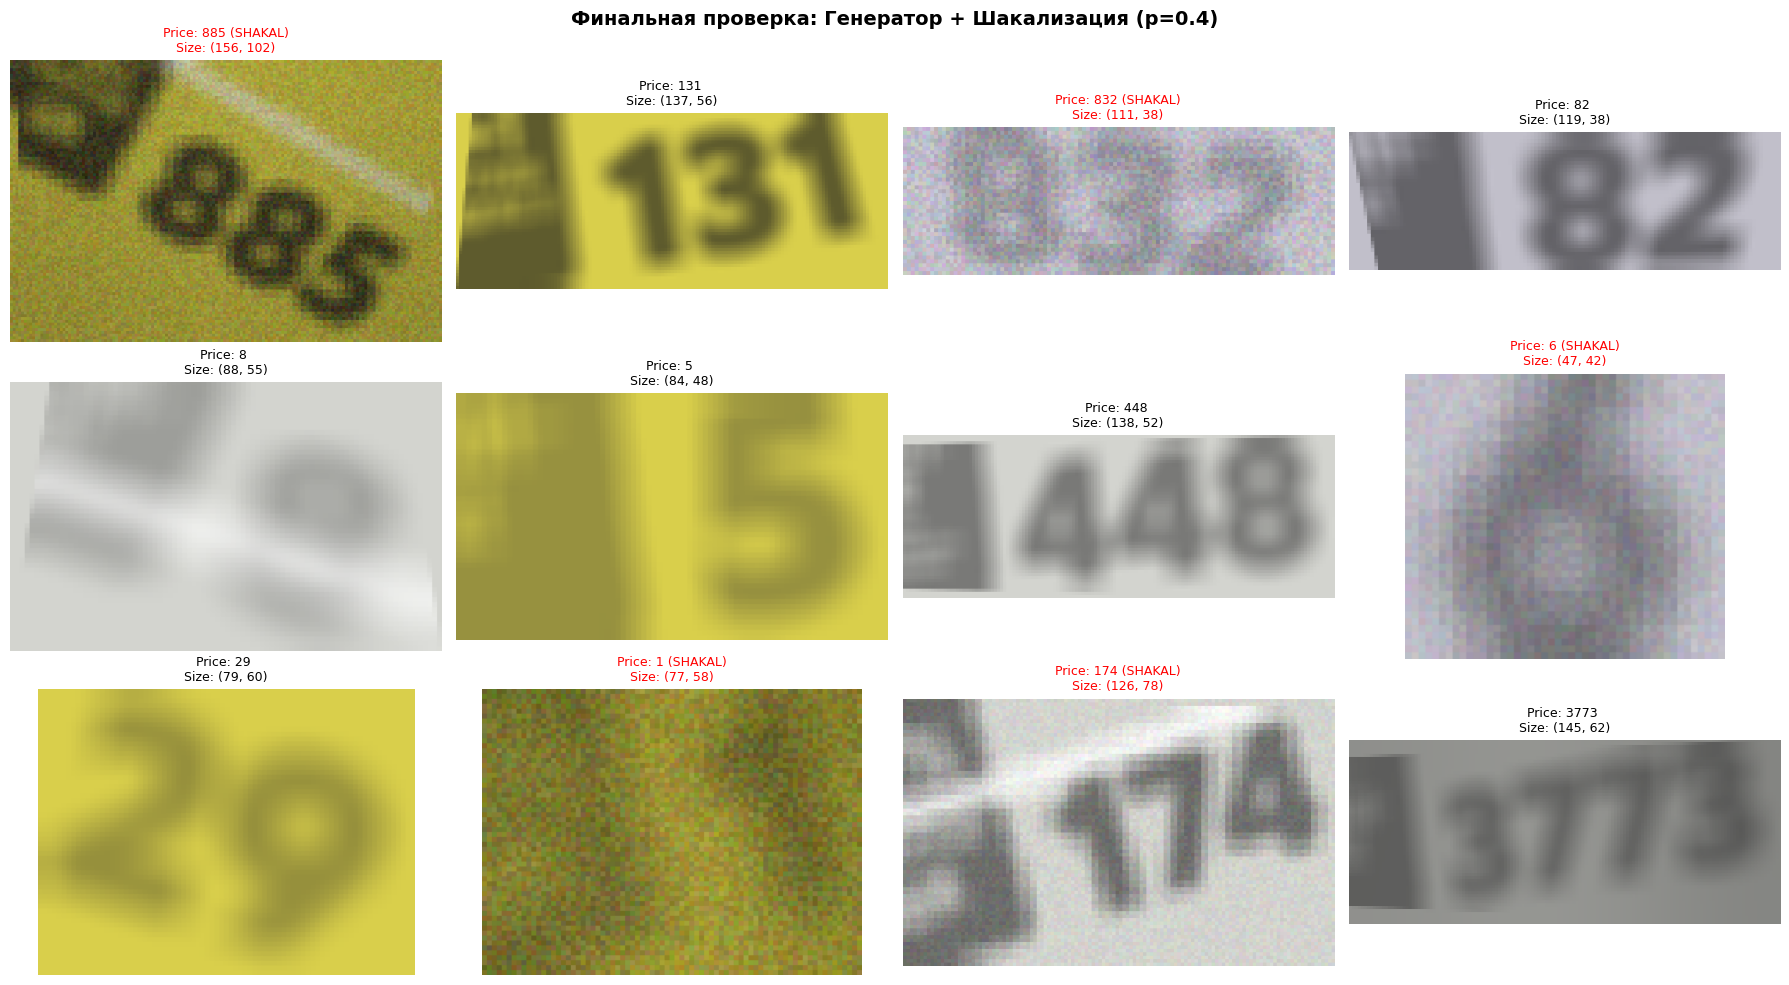

In [ ]:
# Финальный тест функции generate_combined_variant_with_icons с эффектом 'Шакал'
all_bg_colors = list(backgrounds.values())
icon_paths = [f'/content/{i}.png' for i in [1, 2, 3, 4]]
final_previews = []

for i in range(12):
    color = random.choice(all_bg_colors)
    # Разная длина текста для проверки динамической обрезки
    txt = str(random.choice([random.randint(1, 9), random.randint(10, 99), random.randint(100, 999), random.randint(1000, 9999)]))
    # 75% шанс иконки
    path = random.choice(icon_paths) if random.random() < 0.75 else None

    img = generate_combined_variant_with_icons(txt, color, icon_path=path)

    # Добавляем эффект 'шакал' с вероятностью 0.4
    is_shakal = False
    if random.random() < 0.4:
        img = apply_shakal_effects(img, shakal_factor=random.uniform(0.3, 0.5), noise_intensity=random.randint(10, 20))
        is_shakal = True

    final_previews.append((txt, img, is_shakal))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, (txt, img, shakal) in enumerate(final_previews):
    # Увеличиваем масштаб для детального осмотра
    display_img = img.resize((img.width * 3, img.height * 3), Image.NEAREST)
    axes[idx].imshow(display_img)
    status = "(SHAKAL)" if shakal else ""
    axes[idx].set_title(f"Price: {txt} {status}\nSize: {img.size}", fontsize=9, color='red' if shakal else 'black')
    axes[idx].axis('off')

plt.suptitle('Финальная проверка: Генератор + Шакализация (p=0.4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

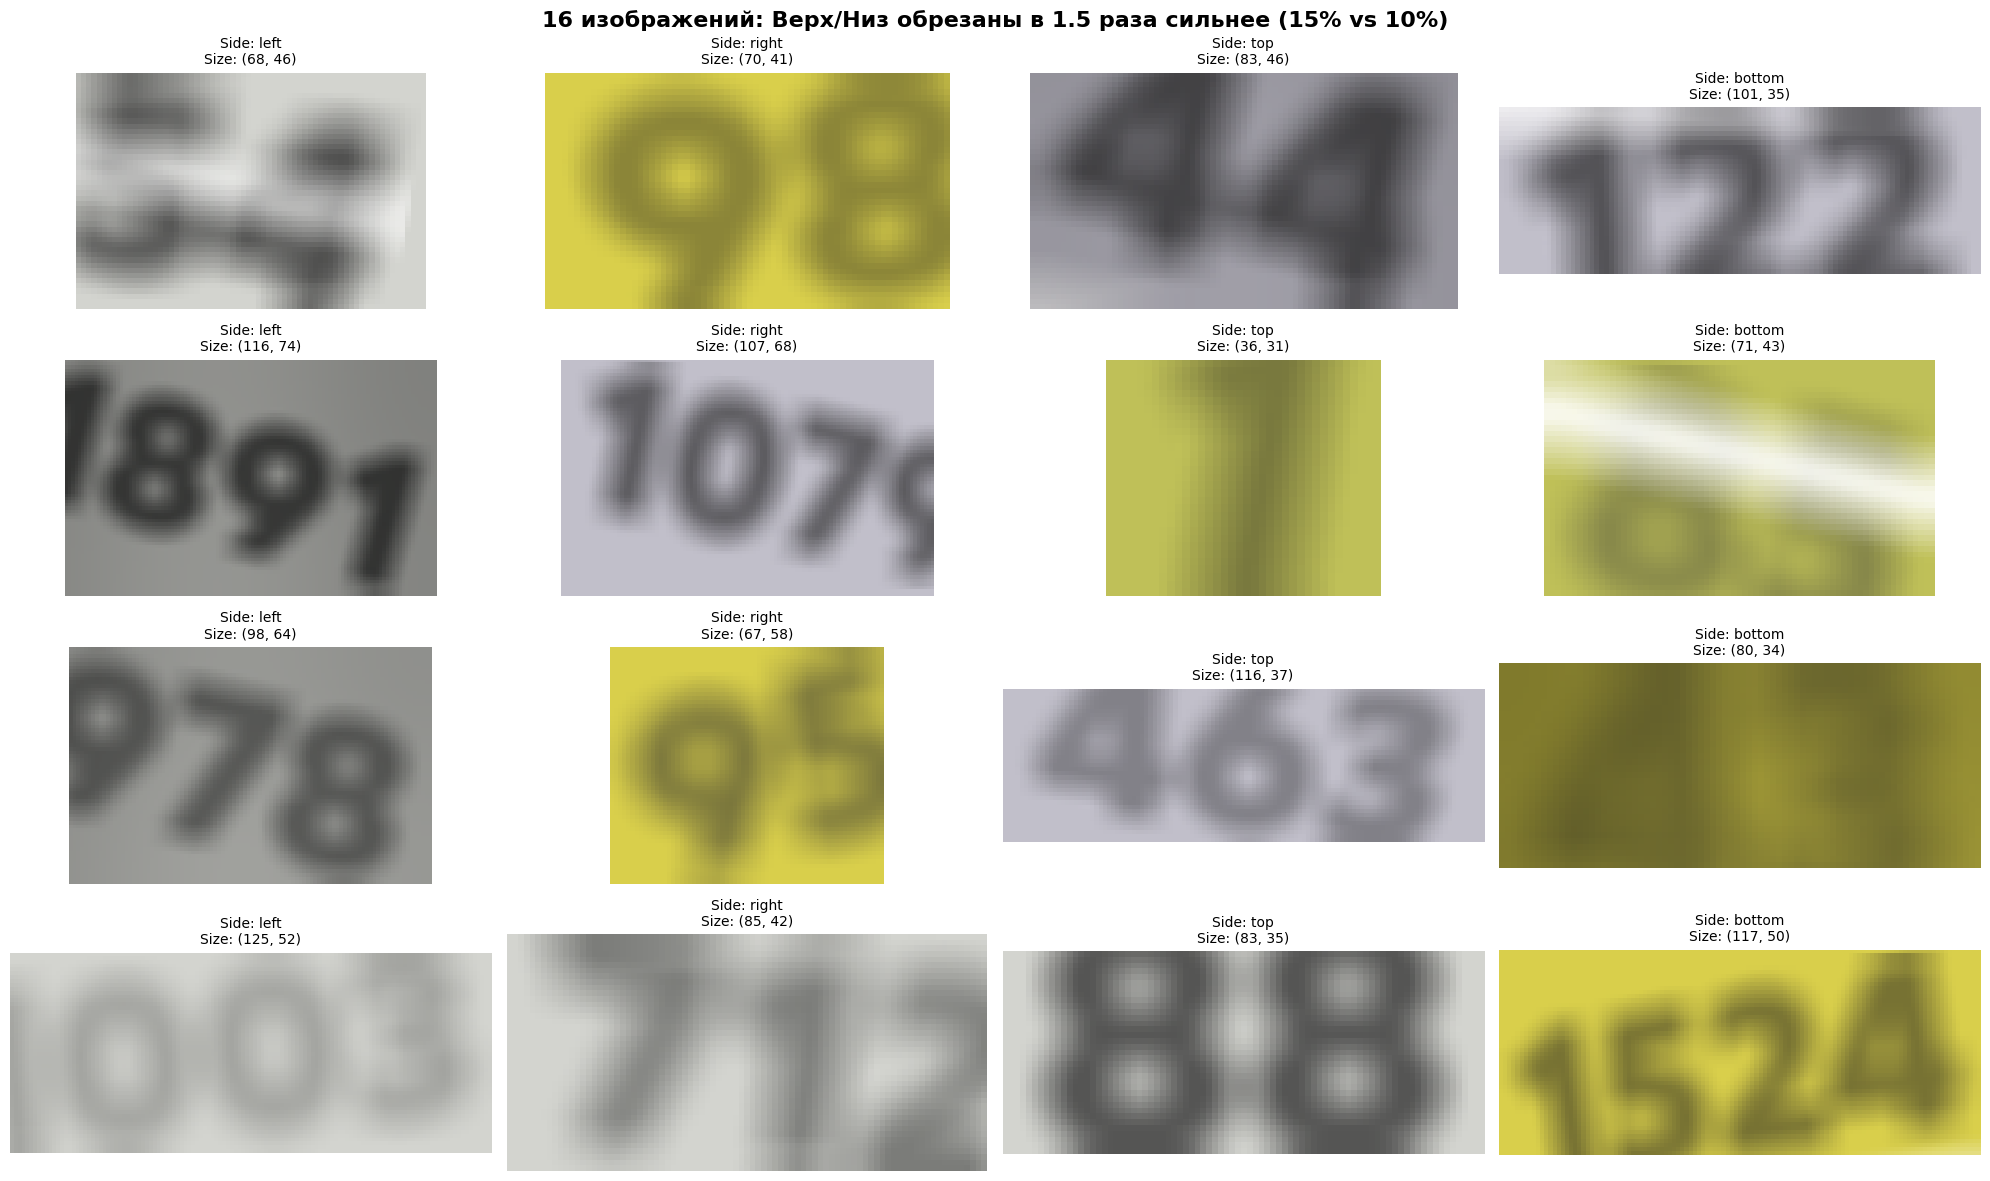

In [ ]:
import random
import os
import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot
import matplotlib.pyplot as plt

def apply_one_side_crop(img, base_strength=0.15, side=None):
    """Обрезает сторону, при этом верх/низ в 1.25 раза сильнее чем лево/право"""
    w, h = img.size
    if side is None:
        side = random.choice(['left', 'right', 'top', 'bottom'])

    if side in ['top', 'bottom']:
        strength = base_strength * 1.25
    else:
        strength = base_strength

    if side == 'left':
        return img.crop((int(w * strength), 0, w, h))
    elif side == 'right':
        return img.crop((0, 0, int(w * (1 - strength)), h))
    elif side == 'top':
        return img.crop((0, int(h * strength), w, h))
    else: # bottom
        return img.crop((0, 0, w, int(h * (1 - strength))))

all_bg_colors = list(backgrounds.values())
results = []
sides = ['left', 'right', 'top', 'bottom']

# Параметры пользователя
price_ranges = [(1, 9), (10, 99), (100, 999), (1000, 2000)]
range_weights = [0.075, 0.30, 0.45, 0.175]

for i in range(16):
    color = random.choice(all_bg_colors)
    chosen_range = random.choices(price_ranges, weights=range_weights, k=1)[0]
    txt = str(random.randint(chosen_range[0], chosen_range[1]))

    # Генерируем изображение с углом и перспективой
    img = generate_combined_variant_with_icons(txt, color, max_angle=15)

    # Применяем обрезку (базовая 10%, верх/низ будет 15%)
    side_to_crop = sides[i % 4]
    img_cropped = apply_one_side_crop(img, side=side_to_crop)

    results.append((img_cropped, side_to_crop))

# Визуализация
fig, axes = plt.subplots(4, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, (img, side) in enumerate(results):
    axes[idx].imshow(img)
    axes[idx].set_title(f"Side: {side}\nSize: {img.size}", fontsize=10)
    axes[idx].axis('off')

plt.suptitle("16 изображений: Верх/Низ обрезаны в 1.5 раза сильнее (15% vs 10%)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

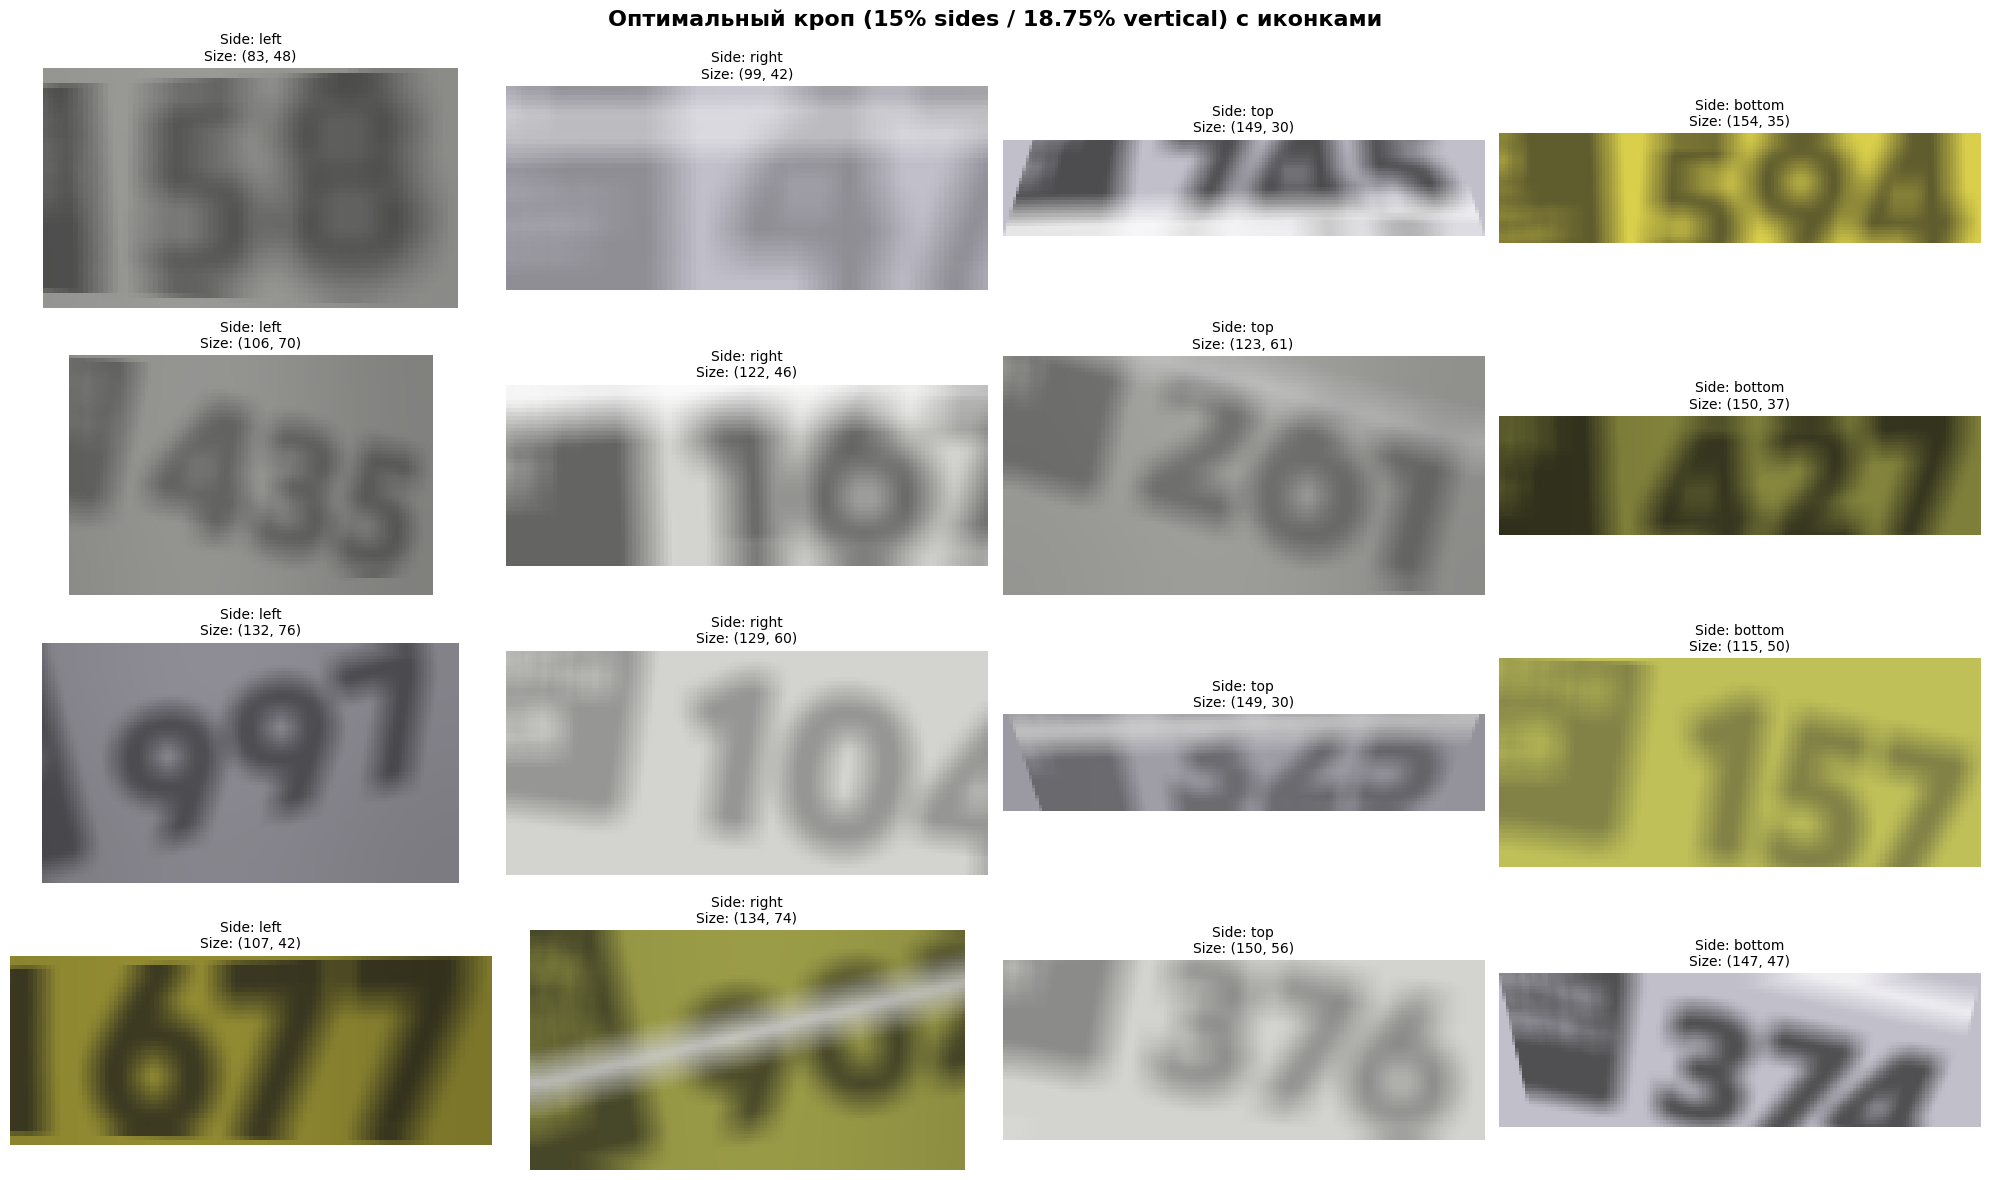

In [ ]:
# Тест оптимального кропа с иконками
icon_paths = [f'/content/{i}.png' for i in [1, 2, 3, 4]]
all_bg_colors = list(backgrounds.values())

results = []
sides = ['left', 'right', 'top', 'bottom']

for i in range(16):
    color = random.choice(all_bg_colors)
    # Генерируем случайную цену
    txt = str(random.randint(10, 999))
    # Берем случайную иконку
    path = random.choice(icon_paths)

    # Генерируем базу
    img = generate_combined_variant_with_icons(txt, color, icon_path=path, max_angle=15)

    # Применяем наш 'оптимум' параметров для кропа
    side_to_crop = sides[i % 4]
    img_cropped = apply_one_side_crop(img, side=side_to_crop)

    results.append((img_cropped, side_to_crop))

# Визуализация
fig, axes = plt.subplots(4, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, (img, side) in enumerate(results):
    axes[idx].imshow(img)
    axes[idx].set_title(f"Side: {side}\nSize: {img.size}", fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Оптимальный кроп (15% sides / 18.75% vertical) с иконками", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import pandas as pd
import random
import numpy as np
from tqdm.auto import tqdm

def apply_one_side_crop(img, base_strength=0.15, side=None):
    """Обрезает сторону, при этом верх/низ в 1.25 раза сильнее чем лево/право"""
    w, h = img.size
    if side is None:
        side = random.choice(['left', 'right', 'top', 'bottom'])

    if side in ['top', 'bottom']:
        strength = base_strength * 1.25
    else:
        strength = base_strength

    if side == 'left':
        return img.crop((int(w * strength), 0, w, h))
    elif side == 'right':
        return img.crop((0, 0, int(w * (1 - strength)), h))
    elif side == 'top':
        return img.crop((0, int(h * strength), w, h))
    else: # bottom
        return img.crop((0, 0, w, int(h * (1 - strength))))

# Настройки
DATASET_DIR = 'price_tags_v5_dataset'
NUM_SAMPLES = 33500
START_INDEX = 0
icon_paths = [f'/content/{i}.png' for i in [1, 2, 3, 4]]

if os.path.exists(DATASET_DIR): shutil.rmtree(DATASET_DIR)
os.makedirs(DATASET_DIR)

print(f"Генерируем {NUM_SAMPLES} образцов (индекс с {START_INDEX})...")
annotations = []

bg_options = list(backgrounds.values())
bg_weights = [0.3, 0.3, 0.2, 0.2]
price_ranges = [(1, 9), (10, 99), (100, 999), (1000, 2000)]
range_weights = [0.075, 0.30, 0.45, 0.175]

for i in tqdm(range(START_INDEX, START_INDEX + NUM_SAMPLES)):
    chosen_range = random.choices(price_ranges, weights=range_weights, k=1)[0]
    if random.random() < 0.25:
        if chosen_range == (1, 9): text = '9'
        else:
            low, high = chosen_range
            prefix = random.randint(low // 10, high // 10)
            val = prefix * 10 + 9
            if val < low: val += 10
            if val > high: val -= 10
            text = str(val)
    else:
        text = str(random.randint(*chosen_range))

    path = None
    if len(text) in [2, 3] and random.random() < 0.15:
        path = random.choice(icon_paths)

    color = random.choices(bg_options, weights=bg_weights, k=1)[0]
    use_hard_stripe = random.random() < 0.1

    # Генерация изображения
    img = generate_combined_variant_with_icons(text, color, icon_path=path, force_hard_stripe=use_hard_stripe)

    # Добавляем кроп с вероятностью 10%
    if random.random() < 0.1:
        img = apply_one_side_crop(img)

    # Шакализация (p=0.5)
    if random.random() < 0.5:
        img = apply_shakal_effects(img, shakal_factor=random.uniform(0.15, 0.3), noise_intensity=random.randint(25, 45))

    filename = f"{i:05d}_{text}.jpg"
    img.save(os.path.join(DATASET_DIR, filename), quality=15)
    annotations.append({'Filename': filename, 'Price': text})

pd.DataFrame(annotations).to_csv(os.path.join(DATASET_DIR, 'annotations.csv'), index=False)
shutil.make_archive(DATASET_DIR, 'zip', DATASET_DIR)
print(f"Готово: {DATASET_DIR}.zip")

from google.colab import files
files.download(f'/content/{DATASET_DIR}.zip')


Генерируем 33500 образцов (индекс с 0)...


  0%|          | 0/33500 [00:00<?, ?it/s]

Готово: price_tags_v5_dataset.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>